<a href="https://www.kaggle.com/code/gpreda/economic-accounts-for-agriculture-in-eu?scriptVersionId=259191410" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Introduction

This notebook analyses the [Economic accounts for agriculture in Europe](https://www.kaggle.com/datasets/gpreda/economic-accounts-for-agriculture-in-europe) dataset.


# Read data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/economic-accounts-for-agriculture-in-europe/aact_eea04.csv")

In [3]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,DATAFLOW,LAST UPDATE,freq,itm_newa,indic_ag,unit,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:AACT_EAA04$DEFAULTVIEW(1.0),15/05/24 11:00:00,Annual,Crop output,Production value at basic price,"Chain linked volumes (2010), million euro",Austria,2015,2669.58,NaN,NaN
1,ESTAT:AACT_EAA04$DEFAULTVIEW(1.0),15/05/24 11:00:00,Annual,Crop output,Production value at basic price,"Chain linked volumes (2010), million euro",Austria,2016,2671.63,NaN,NaN
2,ESTAT:AACT_EAA04$DEFAULTVIEW(1.0),15/05/24 11:00:00,Annual,Crop output,Production value at basic price,"Chain linked volumes (2010), million euro",Austria,2017,2703.96,NaN,NaN
3,ESTAT:AACT_EAA04$DEFAULTVIEW(1.0),15/05/24 11:00:00,Annual,Crop output,Production value at basic price,"Chain linked volumes (2010), million euro",Austria,2018,2749.02,NaN,NaN
4,ESTAT:AACT_EAA04$DEFAULTVIEW(1.0),15/05/24 11:00:00,Annual,Crop output,Production value at basic price,"Chain linked volumes (2010), million euro",Austria,2019,2694.85,NaN,NaN


# Data exploration


Let's first understand what are the frequencies, list of products,  agricultural indicator, units, geographies, years are.

In [4]:
print(f"Frequency: {list(df.freq.unique())}")

Frequency: ['Annual']


In [5]:
print(f"List of products: {list(df.itm_newa.unique())}")

List of products: ['Crop output', 'Animal output', 'Agricultural output', "Output of the agricultural 'industry'", 'Total intermediate consumption', 'Gross value added at basic prices', 'Factor income', 'Entrepreneurial income', 'Gross fixed capital formation (excluding deductible VAT)']


In [6]:
print(f"Agricultural indicator: {list(df.indic_ag.unique())}")

Agricultural indicator: ['Production value at basic price']


In [7]:
print(f"Units: {list(df.unit.unique())}")

Units: ['Chain linked volumes (2010), million euro', 'Chain linked volumes (2010), million units of national currency', 'Chain linked volumes (2015), million euro', 'Chain linked volumes (2015), million units of national currency', 'Chain linked volumes, previous year, million euro', 'Chain linked volumes, previous year, million units of national currency']


In [8]:
print(f"Geographies: {list(df.geo.unique())}")

Geographies: ['Austria', 'Belgium', 'Bulgaria', 'Switzerland', 'Cyprus', 'Czechia', 'Germany', 'Denmark', 'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023)', 'Estonia', 'Greece', 'Spain', 'European Union (EU6-1958, EU9-1973, EU10-1981, EU12-1986, EU15-1995, EU25-2004, EU27-2007, EU28-2013, EU27-2020)', 'European Union - 27 countries (from 2020)', 'European Union - 27 countries (from 2020) and European Free Trade Association (EFTA) countries', 'Finland', 'France', 'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy', 'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Sweden', 'Slovenia', 'Slovakia', 'United Kingdom']


In [9]:
print(f"Years: {list(df.TIME_PERIOD.unique())}")

Years: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


# Data visualization

## Configurations

In [10]:
PREFERRED_UNIT    = "Chain linked volumes (2015), million euro"
PREFERRED_PRODUCT = "Agricultural output"         # for geo-comparison plots
PREFERRED_GEO     = "France"                      # for product-breakdown plots
TOP_N_GEOS        = 12                            # show top-N geos by latest value
START_YEAR        = 2015                          # optional: lower bound on year

## Basic preparations

In [11]:
def prep(df):
    df = df.copy()
    # keep Annual, preferred unit (adjust if you want multiple units)
    df = df[df["freq"].str.lower().eq("annual")]
    if PREFERRED_UNIT in set(df["unit"]):
        df = df[df["unit"].eq(PREFERRED_UNIT)]
    # focus years (optional)
    if START_YEAR is not None:
        df = df[df["TIME_PERIOD"] >= START_YEAR]
    # numeric
    df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
    df["TIME_PERIOD"] = pd.to_numeric(df["TIME_PERIOD"], errors="coerce")
    df = df.dropna(subset=["OBS_VALUE","TIME_PERIOD","geo","itm_newa"])
    return df

In [12]:
df_clean = prep(df)

## Helper function

Add a helper function to put the legend nice outside.

In [13]:
def put_legend_outside(ax, title=None, ncol=3, loc="center left"):
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend_.remove() if ax.get_legend() else None
        ax.figure.legend(
            handles, labels, title=title,
            loc="upper center", bbox_to_anchor=(0.5, -0.06), ncol=ncol
        )


## Visualization functions

### Time series: all countries for ONE product (PREFERRED_PRODUCT)

In [14]:
def plot_timeseries_by_geo_for_product(df):
    d = df[df["itm_newa"].eq(PREFERRED_PRODUCT)]
    if d.empty:
        print(f"[WARN] No rows for product: {PREFERRED_PRODUCT}")
        return
    # choose top-N geos by latest year value
    latest_year = d["TIME_PERIOD"].max()
    top_geos = (d[d["TIME_PERIOD"].eq(latest_year)]
                .nlargest(TOP_N_GEOS, "OBS_VALUE")["geo"].tolist())
    d = d[d["geo"].isin(top_geos)]

    fig, ax = plt.subplots(figsize=(12, 6))
    for geo, g in d.groupby("geo"):
        g = g.sort_values("TIME_PERIOD")
        ax.plot(g["TIME_PERIOD"], g["OBS_VALUE"], marker="o", label=geo[0:50], lw=2)

    ax.set_title(f"{PREFERRED_PRODUCT} — {PREFERRED_UNIT}\nTop {len(top_geos)} countries by {latest_year}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    ax.grid(True, ls="--", alpha=0.4)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Country")
    fig.tight_layout()
    plt.show()



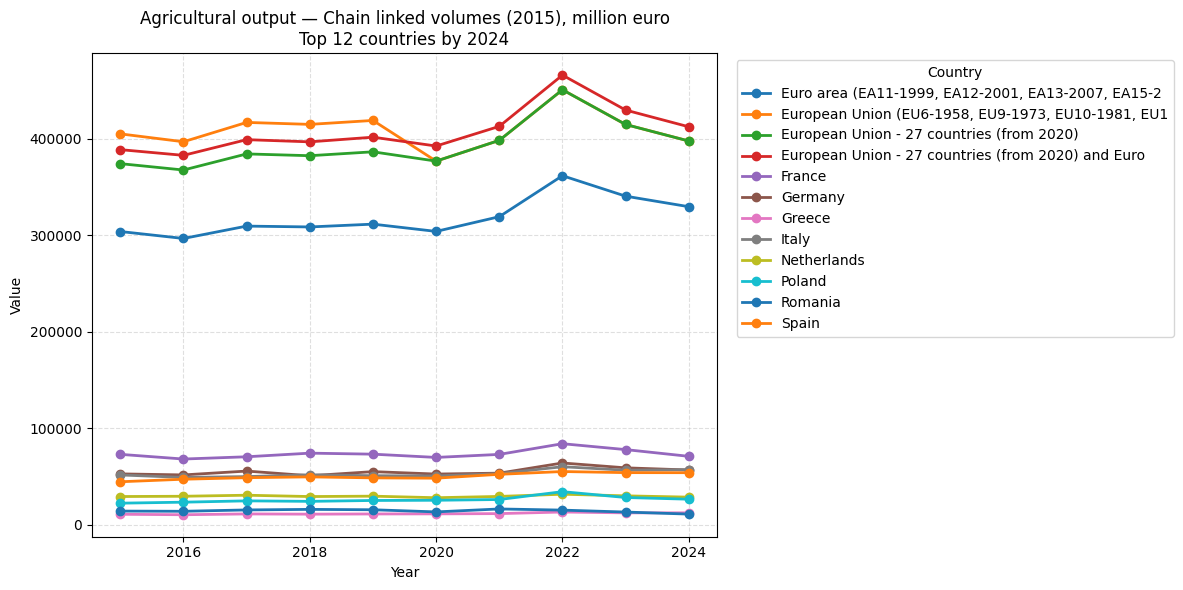

In [15]:
plot_timeseries_by_geo_for_product(df_clean)

### Bar chart: latest year, by country, for ONE product

In [16]:
def plot_latest_bar_by_geo_for_product(df):
    d = df[df["itm_newa"].eq(PREFERRED_PRODUCT)]
    if d.empty:
        print(f"[WARN] No rows for product: {PREFERRED_PRODUCT}")
        return
    latest_year = d["TIME_PERIOD"].max()
    d = d[d["TIME_PERIOD"].eq(latest_year)].sort_values("OBS_VALUE", ascending=False)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(d["geo"], d["OBS_VALUE"])
    ax.set_title(f"{PREFERRED_PRODUCT} — {PREFERRED_UNIT}\nLatest year {latest_year}")
    ax.set_xlabel("Country")
    ax.set_ylabel("Value")
    ax.set_xticks(range(len(d["geo"])))
    ax.set_xticklabels(d["geo"], rotation=60, ha="right")
    ax.grid(True, axis="y", ls="--", alpha=0.4)
    fig.tight_layout()
    plt.show()


/tmp/ipykernel_13/4157434011.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


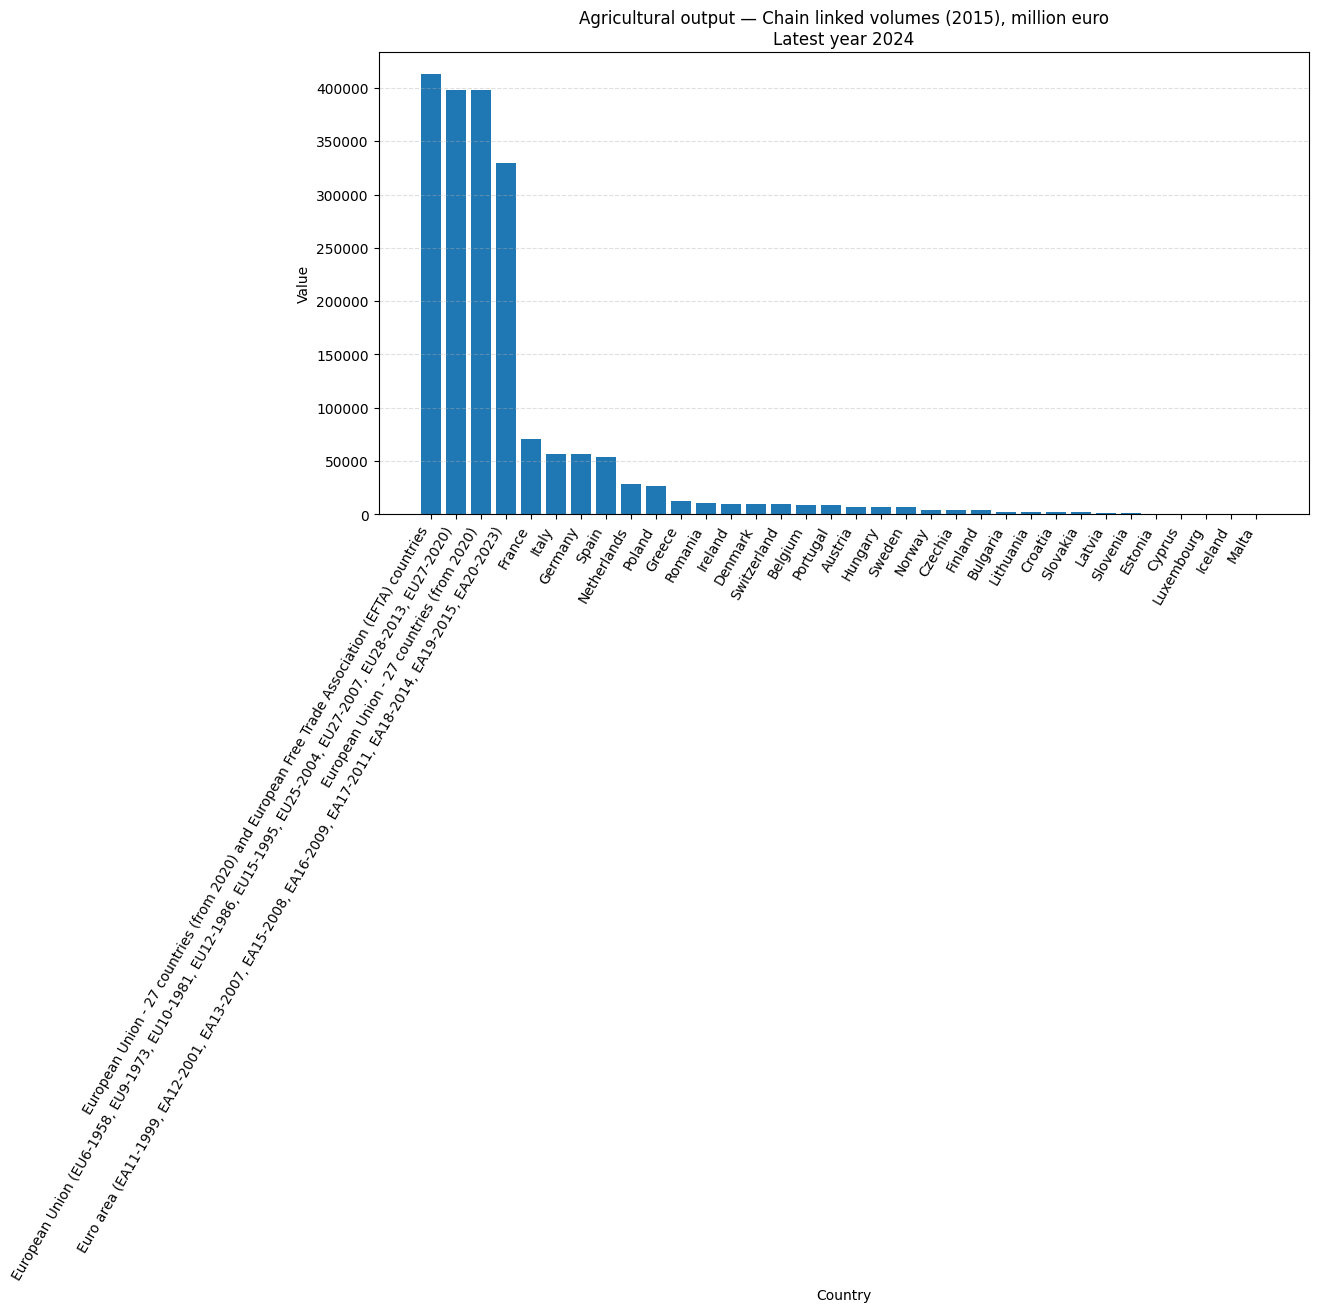

In [17]:
plot_latest_bar_by_geo_for_product(df_clean)

### Grid: ONE country, ALL products (lines over time)

In [18]:
def plot_grid_products_for_one_geo(df, country=PREFERRED_GEO):
    d = df[df["geo"].eq(country)].copy()
    if d.empty:
        print(f"[WARN] No rows for geo: {country}")
        return
    products = sorted(d["itm_newa"].unique().tolist())
    n = len(products)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.2*nrows), sharex=True)
    axes = np.atleast_2d(axes)

    for i, prod in enumerate(products):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        g = d[d["itm_newa"].eq(prod)].sort_values("TIME_PERIOD")
        ax.plot(g["TIME_PERIOD"], g["OBS_VALUE"], marker="o", lw=2, label=prod)
        ax.set_title(prod, fontsize=10)
        ax.grid(True, ls="--", alpha=0.35)

    # remove empty axes
    for j in range(n, nrows*ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r, c])

    fig.suptitle(f"{country} — {PREFERRED_UNIT}", y=1.02, fontsize=13)
    for ax in axes[-1, :]:
        if ax in fig.axes:
            ax.set_xlabel("Year")
    for r in range(nrows):
        axes[r,0].set_ylabel("Value")
    fig.tight_layout()
    plt.show()

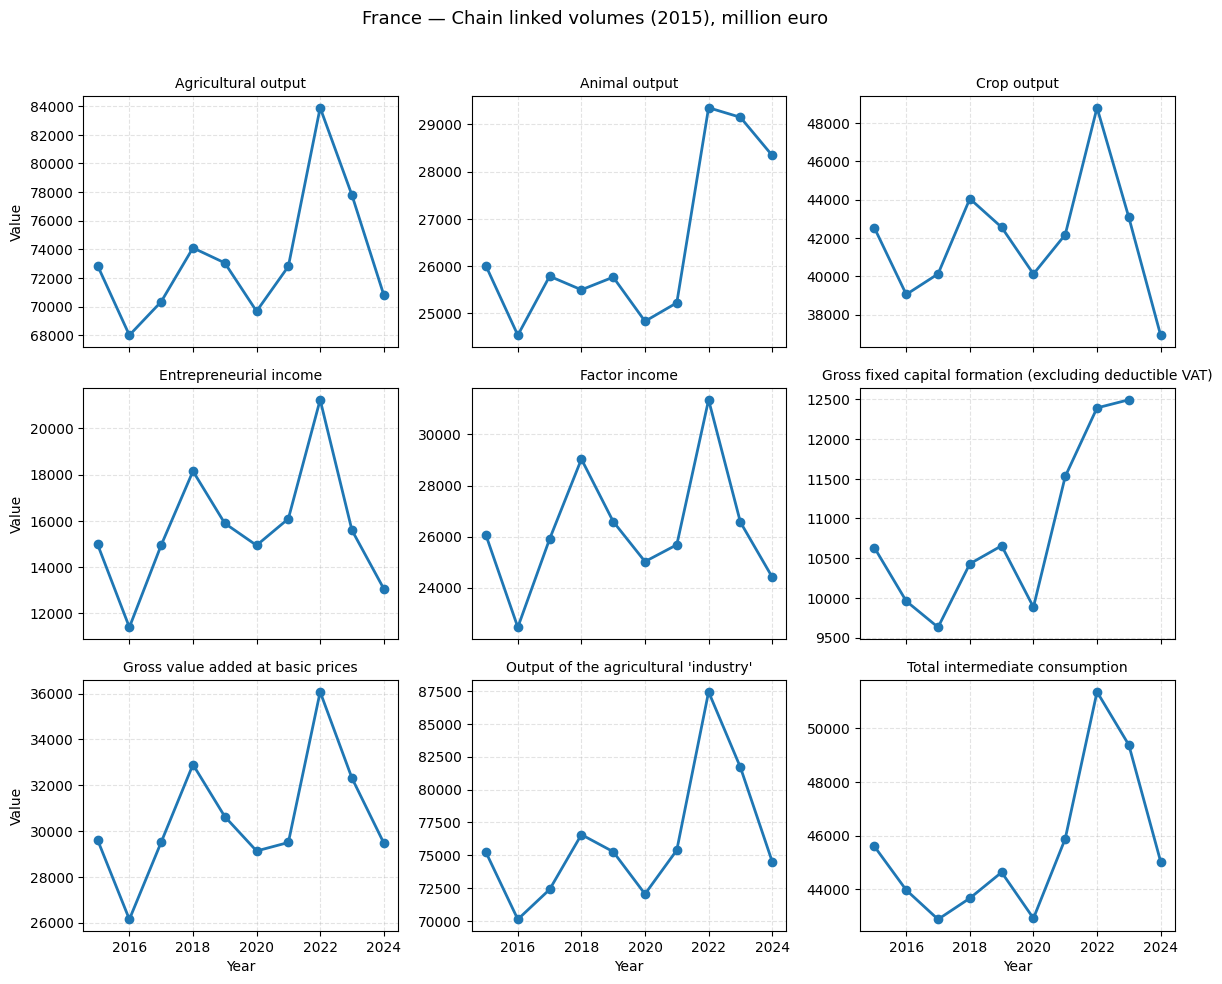

In [19]:
plot_grid_products_for_one_geo(df_clean)

Let's show for few alternative country as well.

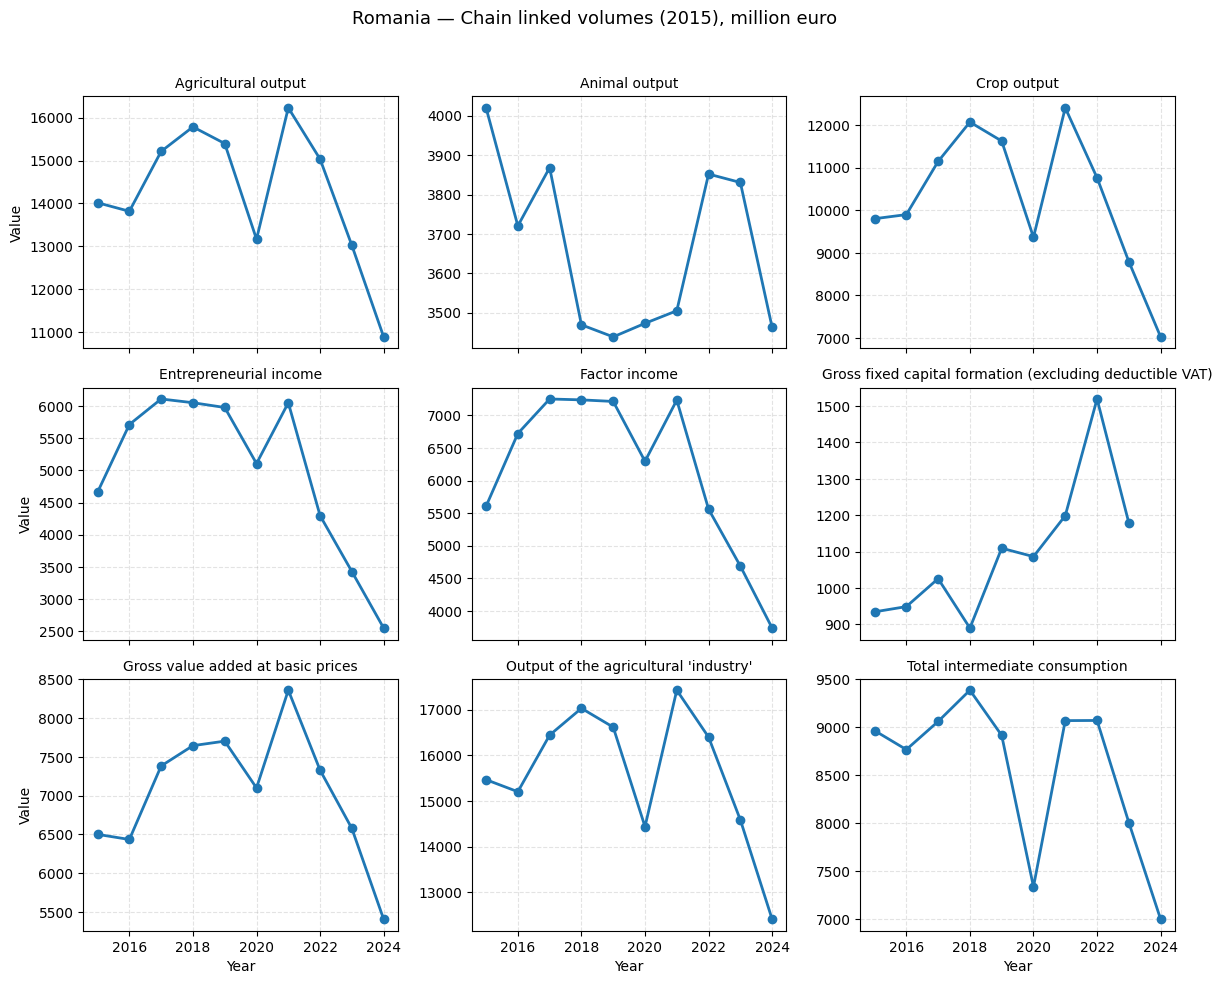

In [20]:
plot_grid_products_for_one_geo(df_clean, country="Romania")

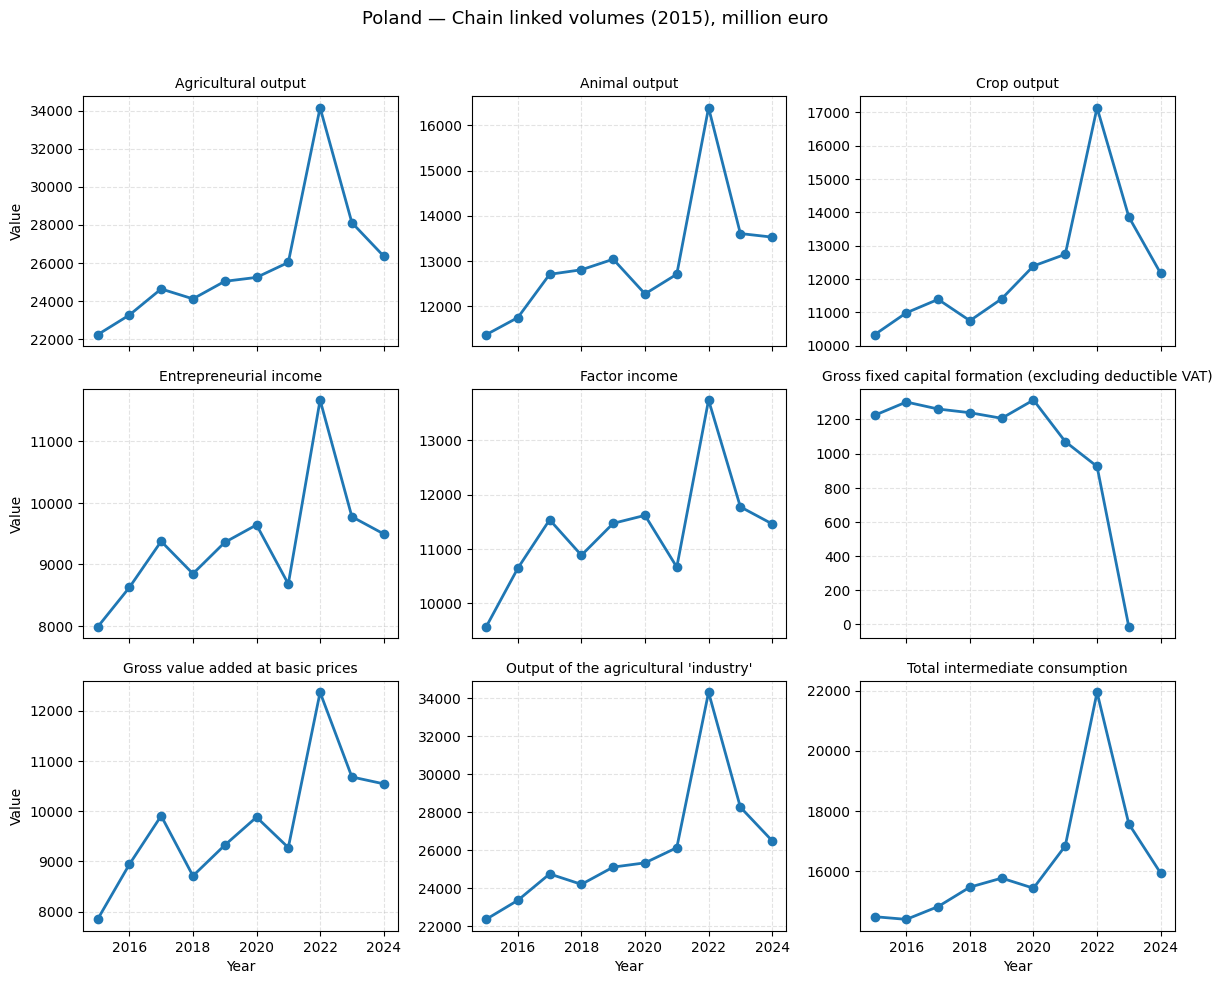

In [21]:
plot_grid_products_for_one_geo(df_clean, country="Poland")

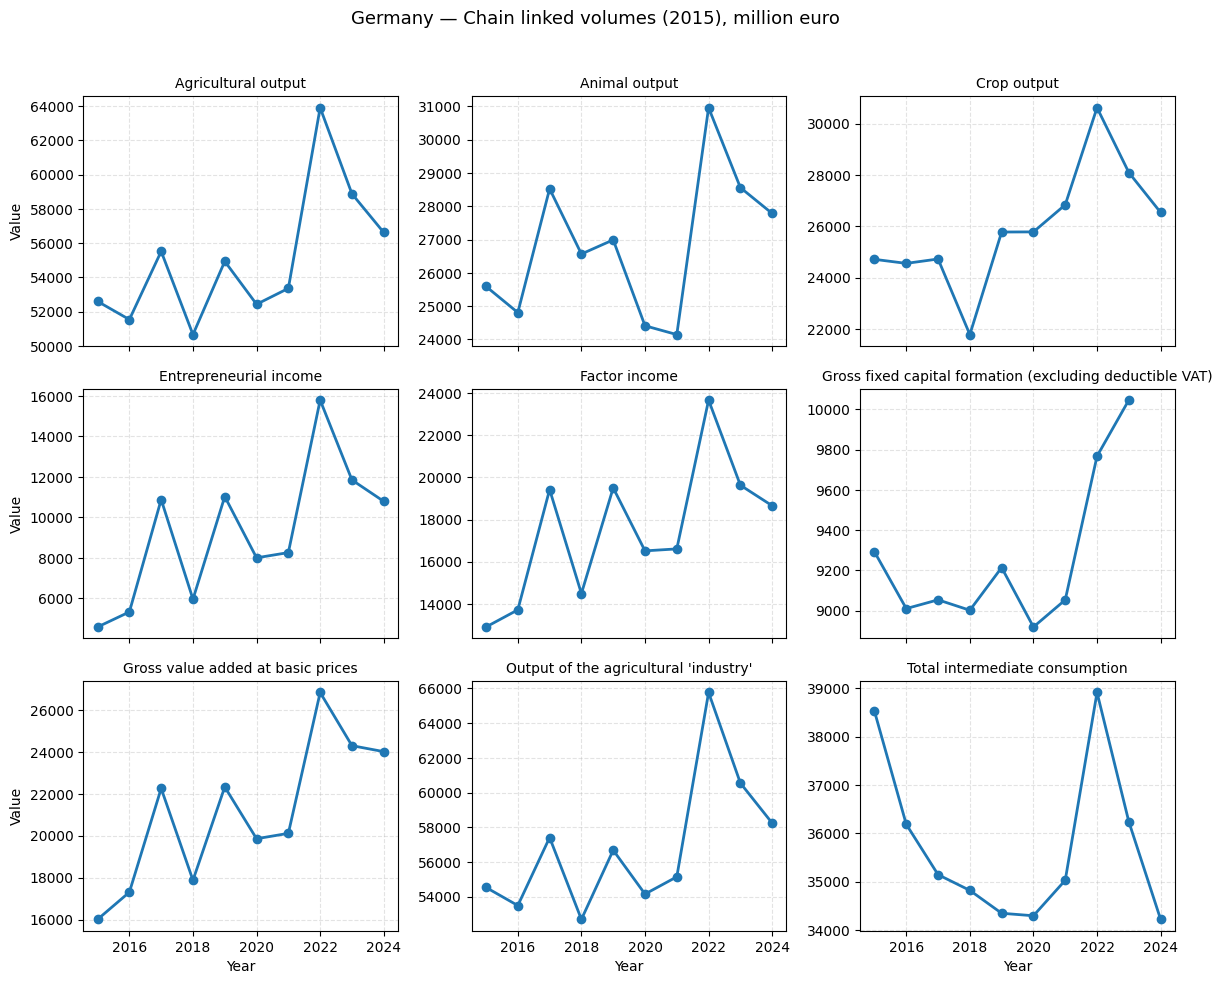

In [22]:
plot_grid_products_for_one_geo(df_clean, country="Germany")

### Stacked area: ONE country — composition across products

In [23]:
def plot_stacked_area_for_one_geo(df, country=PREFERRED_GEO):
    d = df[df["geo"].eq(country)]
    if d.empty:
        print(f"[WARN] No rows for geo: {country}")
        return
    # pivot to TIME_PERIOD x product
    P = (d.pivot_table(index="TIME_PERIOD", columns="itm_newa", values="OBS_VALUE", aggfunc="mean")
           .sort_index())
    # drop columns that are all NaN
    P = P.dropna(axis=1, how="all")
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(P.index.values, P.T.values, labels=P.columns)
    ax.set_title(f"{country} — composition across products (stacked area)\n{PREFERRED_UNIT}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Value")
    ax.grid(True, ls="--", alpha=0.35)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Product")
    fig.tight_layout()
    plt.show()

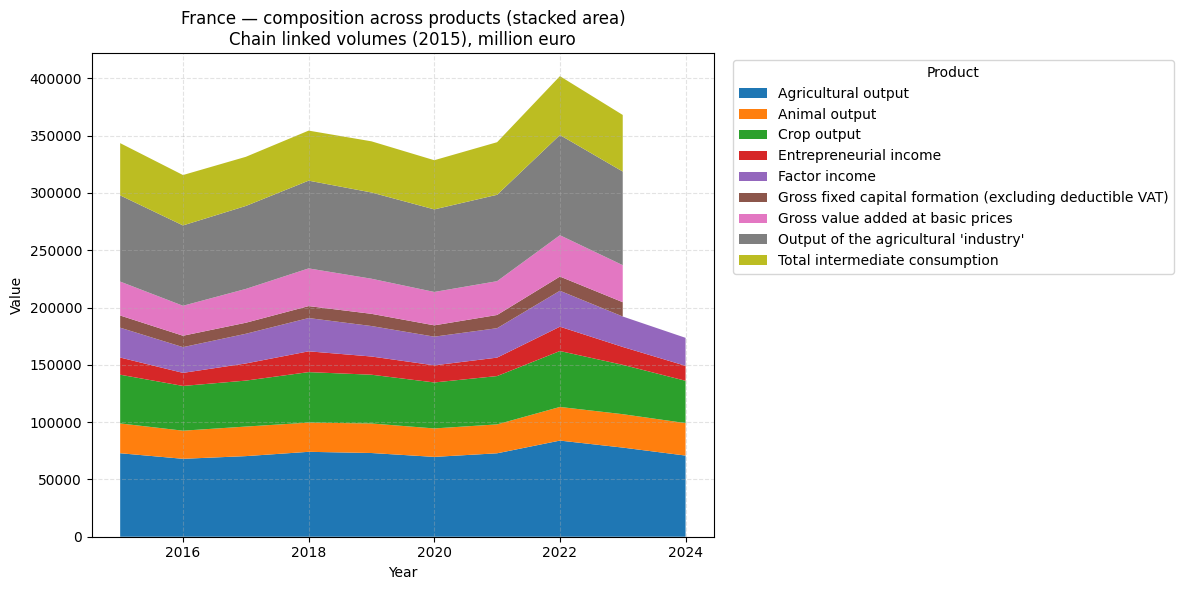

In [24]:
plot_stacked_area_for_one_geo(df_clean)

Let's present for few alternative geographies.

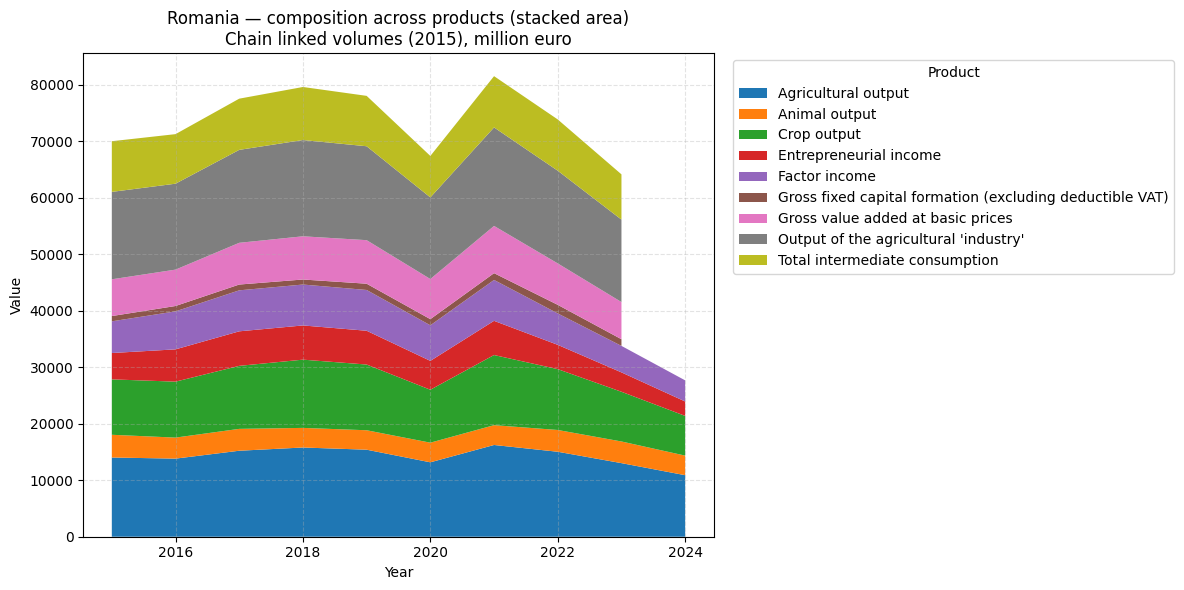

In [25]:
plot_stacked_area_for_one_geo(df_clean, country="Romania")

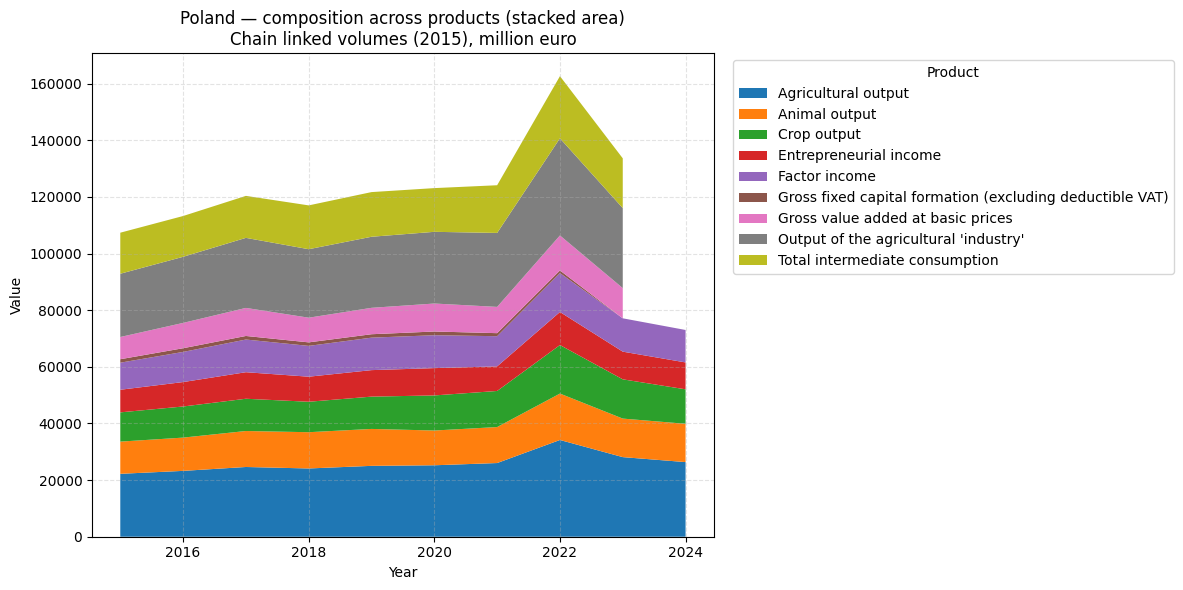

In [26]:
plot_stacked_area_for_one_geo(df_clean, country="Poland")

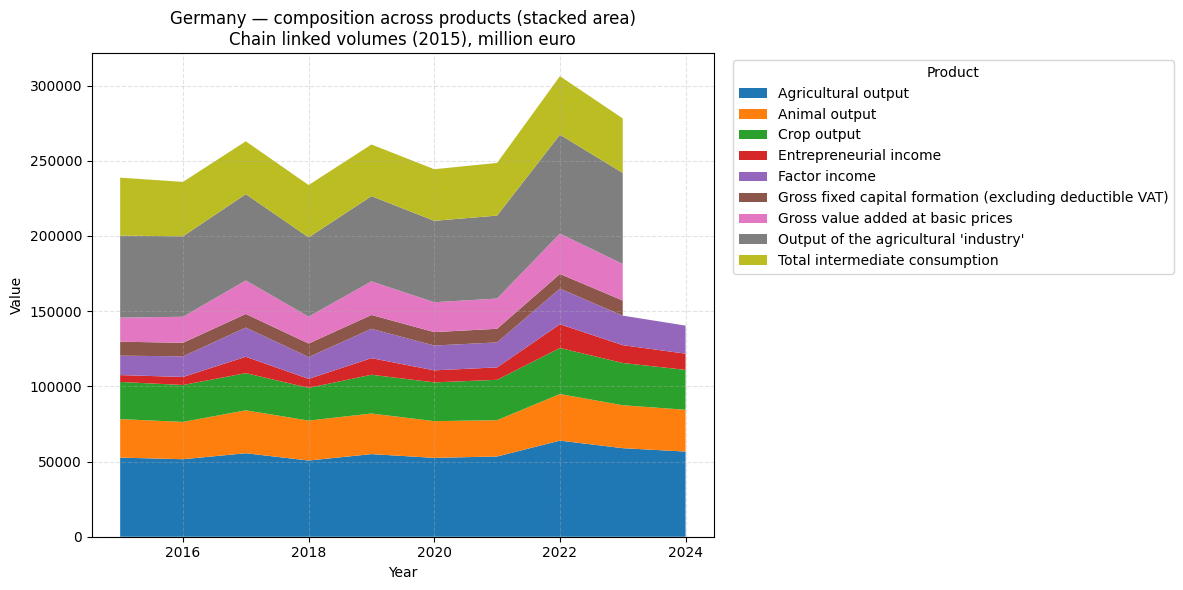

In [27]:
plot_stacked_area_for_one_geo(df_clean, country="Germany")